In [1]:
# importing sys
import sys
# This is how you import modules that exist outside of working directory 
# adding mosaique to the system path
sys.path.insert(1, '/workspaces/QML-QPF/mosaiQue') 

import mosaique as mq


import scipy
import itertools
import pennylane as qml
import os
from tensorflow import keras
import tensorflow as tf 
from matplotlib import pyplot as plt

from Entropy import compute_entropy_for_pair_batch
import concurrent.futures
import numpy as np
import time


2025-10-04 06:51:37.522841: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-04 06:51:37.564418: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Structure

In [23]:
Data_Info = {"Mnist": {"Dataset": {"tr_images" :"",
                              "tr_labels" :"",
                              "te_images" :"",
                              "te_labels" :""
                              },
                      #  configuration that yields the best validation accuracy
                      # only for 4 FC
                       "Configs": { "P_diagonal_config" : np.asarray([0,3,2,1]),
                                    "P_vertical_config" : np.asarray([1,0,3,2]),
                                    "P_horizontal_config" : np.asarray([1,3,2,0])
                                  },
                  
                  "Entropy" :{"Diagonal": {
                                "Total_Avg_Diagonal_Entropy_S1": [],
                                "Total_Max_Diagonal_Entropy_S1": [],
                                "Total_Avg_Diagonal_Entropy_S2": [],
                                "Total_Max_Diagonal_Entropy_S2": [],
                                "Total_Avg_Diagonal_Entropy_S1_S2":[],
                                "Total_Max_Diagonal_Entropy_S1_S2":[]
                                },
                              "Vertical": { 
                                "Total_Avg_Vertical_Entropy_S1": [],
                                "Total_Max_Vertical_Entropy_S1": [],
                                "Total_Avg_Vertical_Entropy_S2": [],
                                "Total_Max_Vertical_Entropy_S2": [],
                                "Total_Avg_Vertical_Entropy_S1_S2": [],
                                "Total_Max_Vertical_Entropy_S1_S2": []
                                },
                              "Horizontal" : {
                                  "Total_Avg_Horizontal_Entropy_S1": [],
                                  "Total_Max_Horizontal_Entropy_S1": [],
                                  "Total_Avg_Horizontal_Entropy_S2": [],
                                  "Total_Max_Horizontal_Entropy_S2": [], 
                                  "Total_Avg_Horizontal_Entropy_S1_S2": [],   
                                  "Total_Max_Horizontal_Entropy_S1_S2": []          
                                }
                  }
                },
                  
        
        "Fashion Mnist": {"Dataset": {"tr_images" :"",
                              "tr_labels" :"",
                              "te_images" :"",
                              "te_labels" :""
                              },
                          #  configuration that yields the best validation accuracy
                       "Configs": { "P_diagonal_config" : np.asarray([1,2,3,0]),
                                    "P_vertical_config" : np.asarray([0,1,3,2]),
                                    "P_horizontal_config" : np.asarray([2,0,1,3])
                                  },
                  "Entropy" :{"Diagonal": {
                                "Total_Avg_Diagonal_Entropy_S1": [],
                                "Total_Max_Diagonal_Entropy_S1": [],
                                "Total_Avg_Diagonal_Entropy_S2": [],
                                "Total_Max_Diagonal_Entropy_S2": [],
                                "Total_Avg_Diagonal_Entropy_S1_S2":[],
                                "Total_Max_Diagonal_Entropy_S1_S2":[]
                                },
                              "Vertical": { 
                                "Total_Avg_Vertical_Entropy_S1": [],
                                "Total_Max_Vertical_Entropy_S1": [],
                                "Total_Avg_Vertical_Entropy_S2": [],
                                "Total_Max_Vertical_Entropy_S2": [],
                                "Total_Avg_Vertical_Entropy_S1_S2": [],
                                "Total_Max_Vertical_Entropy_S1_S2": []
                                },
                              "Horizontal" : {
                                  "Total_Avg_Horizontal_Entropy_S1": [],
                                  "Total_Max_Horizontal_Entropy_S1": [],
                                  "Total_Avg_Horizontal_Entropy_S2": [],
                                  "Total_Max_Horizontal_Entropy_S2": [], 
                                  "Total_Avg_Horizontal_Entropy_S1_S2": [],   
                                  "Total_Max_Horizontal_Entropy_S1_S2": []          
                                }
                  }
                },
        
         "eMnist Digits": {"Dataset": {"tr_images" :"",
                              "tr_labels" :"",
                              "te_images" :"",
                              "te_labels" :""
                              },
                           #  configuration that yields the best validation accuracy
                       "Configs": { "P_diagonal_config" : np.asarray([2,1,3,0]),
                                    "P_vertical_config" : np.asarray([1,0,2,3]),
                                    "P_horizontal_config" : np.asarray([2,0,1,3])
                                  },
                  "Entropy" :{"Diagonal": {
                                "Total_Avg_Diagonal_Entropy_S1": [],
                                "Total_Max_Diagonal_Entropy_S1": [],
                                "Total_Avg_Diagonal_Entropy_S2": [],
                                "Total_Max_Diagonal_Entropy_S2": [],
                                "Total_Avg_Diagonal_Entropy_S1_S2":[],
                                "Total_Max_Diagonal_Entropy_S1_S2":[]
                                },
                              "Vertical": { 
                                "Total_Avg_Vertical_Entropy_S1": [],
                                "Total_Max_Vertical_Entropy_S1": [],
                                "Total_Avg_Vertical_Entropy_S2": [],
                                "Total_Max_Vertical_Entropy_S2": [],
                                "Total_Avg_Vertical_Entropy_S1_S2": [],
                                "Total_Max_Vertical_Entropy_S1_S2": []
                                },
                              "Horizontal" : {
                                  "Total_Avg_Horizontal_Entropy_S1": [],
                                  "Total_Max_Horizontal_Entropy_S1": [],
                                  "Total_Avg_Horizontal_Entropy_S2": [],
                                  "Total_Max_Horizontal_Entropy_S2": [], 
                                  "Total_Avg_Horizontal_Entropy_S1_S2": [],   
                                  "Total_Max_Horizontal_Entropy_S1_S2": []          
                                }
                  }
                },
         
         "PneumoniaMNIST": {"Dataset": {"tr_images" :"",
                              "tr_labels" :"",
                              "te_images" :"",
                              "te_labels" :""
                              },
                          #  configuration that yields the best validation accuracy
                       "Configs": { "P_diagonal_config" : np.asarray([0,3,2,1]),
                                    "P_vertical_config" : np.asarray([2,3,0,1]),
                                    "P_horizontal_config" : np.asarray([3,1,0,2])
                                  },
                  "Entropy" :{"Diagonal": {
                                "Total_Avg_Diagonal_Entropy_S1": [],
                                "Total_Max_Diagonal_Entropy_S1": [],
                                "Total_Avg_Diagonal_Entropy_S2": [],
                                "Total_Max_Diagonal_Entropy_S2": [],
                                "Total_Avg_Diagonal_Entropy_S1_S2":[],
                                "Total_Max_Diagonal_Entropy_S1_S2":[]
                                },
                              "Vertical": { 
                                "Total_Avg_Vertical_Entropy_S1": [],
                                "Total_Max_Vertical_Entropy_S1": [],
                                "Total_Avg_Vertical_Entropy_S2": [],
                                "Total_Max_Vertical_Entropy_S2": [],
                                "Total_Avg_Vertical_Entropy_S1_S2": [],
                                "Total_Max_Vertical_Entropy_S1_S2": []
                                },
                              "Horizontal" : {
                                  "Total_Avg_Horizontal_Entropy_S1": [],
                                  "Total_Max_Horizontal_Entropy_S1": [],
                                  "Total_Avg_Horizontal_Entropy_S2": [],
                                  "Total_Max_Horizontal_Entropy_S2": [], 
                                  "Total_Avg_Horizontal_Entropy_S1_S2": [],   
                                  "Total_Max_Horizontal_Entropy_S1_S2": []          
                                }
                  }
                },
         
         "BreastMNIST": {"Dataset": {"tr_images" :"",
                              "tr_labels" :"",
                              "te_images" :"",
                              "te_labels" :""
                              },
                          #  configuration that yields the best validation accuracy
                       "Configs": { "P_diagonal_config" : np.asarray([0,3,1,2]),
                                    "P_vertical_config" : np.asarray([0,1,3,2]),
                                    "P_horizontal_config" : np.asarray([2,0,1,3])
                                  },
                  "Entropy" :{"Diagonal": {
                                "Total_Avg_Diagonal_Entropy_S1": [],
                                "Total_Max_Diagonal_Entropy_S1": [],
                                "Total_Avg_Diagonal_Entropy_S2": [],
                                "Total_Max_Diagonal_Entropy_S2": [],
                                "Total_Avg_Diagonal_Entropy_S1_S2":[],
                                "Total_Max_Diagonal_Entropy_S1_S2":[]
                                },
                              "Vertical": { 
                                "Total_Avg_Vertical_Entropy_S1": [],
                                "Total_Max_Vertical_Entropy_S1": [],
                                "Total_Avg_Vertical_Entropy_S2": [],
                                "Total_Max_Vertical_Entropy_S2": [],
                                "Total_Avg_Vertical_Entropy_S1_S2": [],
                                "Total_Max_Vertical_Entropy_S1_S2": []
                                },
                              "Horizontal" : {
                                  "Total_Avg_Horizontal_Entropy_S1": [],
                                  "Total_Max_Horizontal_Entropy_S1": [],
                                  "Total_Avg_Horizontal_Entropy_S2": [],
                                  "Total_Max_Horizontal_Entropy_S2": [], 
                                  "Total_Avg_Horizontal_Entropy_S1_S2": [],   
                                  "Total_Max_Horizontal_Entropy_S1_S2": []          
                                }
                  }
                },
         "OCTMNIST": {"Dataset": {"tr_images" :"",
                              "tr_labels" :"",
                              "te_images" :"",
                              "te_labels" :""
                              },
                          #  configuration that yields the best validation accuracy
                       "Configs": { "P_diagonal_config" : np.asarray([2,1,3,0]),
                                    "P_vertical_config" : np.asarray([2,3,0,1]),
                                    "P_horizontal_config" : np.asarray([2,0,1,3])
                                  },
                  "Entropy" :{"Diagonal": {
                                "Total_Avg_Diagonal_Entropy_S1": [],
                                "Total_Max_Diagonal_Entropy_S1": [],
                                "Total_Avg_Diagonal_Entropy_S2": [],
                                "Total_Max_Diagonal_Entropy_S2": [],
                                "Total_Avg_Diagonal_Entropy_S1_S2":[],
                                "Total_Max_Diagonal_Entropy_S1_S2":[]
                                },
                              "Vertical": { 
                                "Total_Avg_Vertical_Entropy_S1": [],
                                "Total_Max_Vertical_Entropy_S1": [],
                                "Total_Avg_Vertical_Entropy_S2": [],
                                "Total_Max_Vertical_Entropy_S2": [],
                                "Total_Avg_Vertical_Entropy_S1_S2": [],
                                "Total_Max_Vertical_Entropy_S1_S2": []
                                },
                              "Horizontal" : {
                                  "Total_Avg_Horizontal_Entropy_S1": [],
                                  "Total_Max_Horizontal_Entropy_S1": [],
                                  "Total_Avg_Horizontal_Entropy_S2": [],
                                  "Total_Max_Horizontal_Entropy_S2": [], 
                                  "Total_Avg_Horizontal_Entropy_S1_S2": [],   
                                  "Total_Max_Horizontal_Entropy_S1_S2": []          
                                }
                  }
                },
        #  "eMnist Balanced": {"Dataset": {"tr_images" :"",
        #                       "tr_labels" :"",
        #                       "te_images" :"",
        #                       "te_labels" :""
        #                       },
        #           "Entropy" :{"Diagonal": {
        #                         "Total_Avg_Diagonal_Entropy_S1": [],
        #                         "Total_Max_Diagonal_Entropy_S1": [],
        #                         "Total_Avg_Diagonal_Entropy_S2": [],
        #                         "Total_Max_Diagonal_Entropy_S2": [],
        #                         "Total_Avg_Diagonal_Entropy_S1_S2":[],
        #                         "Total_Max_Diagonal_Entropy_S1_S2":[]
        #                         },
        #                       "Vertical": { 
        #                         "Total_Avg_Vertical_Entropy_S1": [],
        #                         "Total_Max_Vertical_Entropy_S1": [],
        #                         "Total_Avg_Vertical_Entropy_S2": [],
        #                         "Total_Max_Vertical_Entropy_S2": [],
        #                         "Total_Avg_Vertical_Entropy_S1_S2": [],
        #                         "Total_Max_Vertical_Entropy_S1_S2": []
        #                         },
        #                       "Horizontal" : {
        #                           "Total_Avg_Horizontal_Entropy_S1": [],
        #                           "Total_Max_Horizontal_Entropy_S1": [],
        #                           "Total_Avg_Horizontal_Entropy_S2": [],
        #                           "Total_Max_Horizontal_Entropy_S2": [], 
        #                           "Total_Avg_Horizontal_Entropy_S1_S2": [],   
        #                           "Total_Max_Horizontal_Entropy_S1_S2": []          
        #                         }
        #           }
        #         },
        
        
         "Maximally Entangled": {"Dataset": {"tr_images" :"",
                              "tr_labels" :"",
                              "te_images" :"",
                              "te_labels" :""
                              },
                                 #  configuration that yields the best validation accuracy
                       "Configs": { "P_diagonal_config" : np.asarray([0,1,2,3]),
                                    "P_vertical_config" : np.asarray([0,1,2,3]),
                                    "P_horizontal_config" : np.asarray([0,1,2,3])
                                  },
                  "Entropy" :{"Diagonal": {
                                "Total_Avg_Diagonal_Entropy_S1": [],
                                "Total_Max_Diagonal_Entropy_S1": [],
                                "Total_Avg_Diagonal_Entropy_S2": [],
                                "Total_Max_Diagonal_Entropy_S2": [],
                                "Total_Avg_Diagonal_Entropy_S1_S2":[],
                                "Total_Max_Diagonal_Entropy_S1_S2":[]
                                },
                              "Vertical": { 
                                "Total_Avg_Vertical_Entropy_S1": [],
                                "Total_Max_Vertical_Entropy_S1": [],
                                "Total_Avg_Vertical_Entropy_S2": [],
                                "Total_Max_Vertical_Entropy_S2": [],
                                "Total_Avg_Vertical_Entropy_S1_S2": [],
                                "Total_Max_Vertical_Entropy_S1_S2": []
                                },
                              "Horizontal" : {
                                  "Total_Avg_Horizontal_Entropy_S1": [],
                                  "Total_Max_Horizontal_Entropy_S1": [],
                                  "Total_Avg_Horizontal_Entropy_S2": [],
                                  "Total_Max_Horizontal_Entropy_S2": [], 
                                  "Total_Avg_Horizontal_Entropy_S1_S2": [],   
                                  "Total_Max_Horizontal_Entropy_S1_S2": []          
                                }
                  }
                },
                 
         } 

## OCTMNIST

In [3]:
def preset():
    # Import the images
    from medmnist import OCTMNIST
    # size of the images 
    size = 28
    # we'll run the code for 64 to see if we'll get different results
    train_data = OCTMNIST(split="train", download=True,size=size)
    test_data = OCTMNIST(split="test", download=True,size=size)
    # name of the folder where will save the filtered images for training
    
    # name of the folder where will save the filtered images for training
    tr_layer = mq.ConvolutionLayer4x4("_OA_results_OCTMNIST_train_with_val")
    # name of the folder where will save the filtered images for testing
    te_layer = mq.ConvolutionLayer4x4("_OA_results_OCTMNIST_test_with_val")
    
    
        
    #load the data set want to train
    (tr_images, tr_labels), (te_images, te_labels) = (train_data.imgs, train_data.labels), (test_data.imgs, test_data.labels)
    

    tr_layer.fit(tr_images)
    te_layer.fit(te_images)
    tr_images = tr_layer.transform(tr_images)
    te_images = te_layer.transform(te_images)
    return ((tr_images, tr_labels),(te_images, te_labels))



In [4]:
# Load the data
(Data_Info["OCTMNIST"]["Dataset"]["tr_images"],\
Data_Info["OCTMNIST"]["Dataset"]["tr_labels"]),\
(Data_Info["OCTMNIST"]["Dataset"]["te_images"],\
Data_Info["OCTMNIST"]["Dataset"]["te_labels"]) = preset()

## BreastMNIST

In [5]:
def preset():
    # Import the images
    from medmnist import BreastMNIST
    # size of the images 
    size = 28
    # we'll run the code for 64 to see if we'll get different results
    train_data = BreastMNIST(split="train", download=True,size=size)
    test_data = BreastMNIST(split="test", download=True,size=size)
    # name of the folder where will save the filtered images for training
    
    # name of the folder where will save the filtered images for training
    tr_layer = mq.ConvolutionLayer4x4("_OA_results_BreastMNIST_train_with_val")
    # name of the folder where will save the filtered images for testing
    te_layer = mq.ConvolutionLayer4x4("_OA_results_BreastMNIST_test_with_val")
    
    
        
    #load the data set want to train
    (tr_images, tr_labels), (te_images, te_labels) = (train_data.imgs, train_data.labels), (test_data.imgs, test_data.labels)
    

    tr_layer.fit(tr_images)
    te_layer.fit(te_images)
    tr_images = tr_layer.transform(tr_images)
    te_images = te_layer.transform(te_images)
    return ((tr_images, tr_labels), (te_images, te_labels))

In [6]:
# Load the data
(Data_Info["BreastMNIST"]["Dataset"]["tr_images"],\
Data_Info["BreastMNIST"]["Dataset"]["tr_labels"]),\
(Data_Info["BreastMNIST"]["Dataset"]["te_images"],\
Data_Info["BreastMNIST"]["Dataset"]["te_labels"]) = preset()

## PneumoniaMNIST

In [7]:
def preset():
    # Import the images
    from medmnist import PneumoniaMNIST
    # size of the images 
    size = 64
    # we'll run the code for 64 to see if we'll get different results
    train_data = PneumoniaMNIST(split="train", download=True,size=size)
    test_data = PneumoniaMNIST(split="test", download=True,size=size)
    # name of the folder where will save the filtered images for training
    tr_layer = mq.ConvolutionLayer4x4("_OA_results_PneumoniaMNIST_train_64")
    # name of the folder where will save the filtered images for testing
    te_layer = mq.ConvolutionLayer4x4("_OA_results_PneumoniaMNIST_test_64")
    
    #load the data set want to train
    (tr_images, tr_labels), (te_images, te_labels) = (train_data.imgs, train_data.labels), (test_data.imgs, test_data.labels)
    # tr_size, tr_h, tr_w, te_size, te_h, te_w = *tr_images.shape, *te_images.shape
    # tr_images, te_images = tr_images.reshape(tr_size, tr_h, tr_w, 1), te_images.reshape(te_size, te_h, te_w, 1)
    
  
    tr_layer.fit(tr_images)
    te_layer.fit(te_images)
    # here is the problem wit transform : shape
    tr_images = tr_layer.transform(tr_images)
    te_images = te_layer.transform(te_images)
    return ((tr_images, tr_labels), (te_images, te_labels))


In [8]:
# Load the data
(Data_Info["PneumoniaMNIST"]["Dataset"]["tr_images"],\
Data_Info["PneumoniaMNIST"]["Dataset"]["tr_labels"]),\
(Data_Info["PneumoniaMNIST"]["Dataset"]["te_images"],\
Data_Info["PneumoniaMNIST"]["Dataset"]["te_labels"]) = preset()

5332

### Mnist 

In [9]:
def preset():
    # load the data
    mnist_dataset = keras.datasets.mnist
    
    # name of the folder where will save the filtered images for training
    tr_layer = mq.ConvolutionLayer4x4("_OA_results_Mnist_train_with_val")
    # name of the folder where will save the filtered images for testing
    te_layer = mq.ConvolutionLayer4x4("_OA_results_Mnist_test_with_val")
    
    
    (tr_images, tr_labels), (te_images, te_labels) = mnist_dataset.load_data()
    
    tr_layer.fit(tr_images)
    te_layer.fit(te_images)
    tr_images = tr_layer.transform(tr_images)
    te_images = te_layer.transform(te_images)
    return ((tr_images, tr_labels), (te_images, te_labels))

In [10]:
# Load the data
(Data_Info["Mnist"]["Dataset"]["tr_images"],\
Data_Info["Mnist"]["Dataset"]["tr_labels"]),\
(Data_Info["Mnist"]["Dataset"]["te_images"],\
Data_Info["Mnist"]["Dataset"]["te_labels"]) = preset()


In [6]:
Data_Info["Mnist"]["Dataset"]["te_images"].shape



(10000, 196, 4)

In [15]:
image = Data_Info["Mnist"]["Dataset"]["tr_images"][3]
image.shape

(196, 4)

## Reshaping to the original image to check

In [ ]:
def reshape_image_from_blocks(start_array):
    """
    Reshapes an array of flattened 2x2 image blocks into a single 28x28 image.

    The input array is expected to have a shape of (196, 4), where each row
    contains the four pixels of a 2x2 block. The pixels within each 2x2 block
    are assumed to be ordered as [top-left, top-right, bottom-left, bottom-right].

    Args:
        start_array (np.ndarray): The input array of shape (196, 4).

    Returns:
        np.ndarray: The reshaped image of shape (28, 28).

    Raises:
        ValueError: If the input array's shape is not (196, 4).
    """
    if start_array.shape != (196, 4):
        raise ValueError(f"Input array must have shape (196, 4), but got {start_array.shape}")

    # Define target image dimensions
    target_height = 28
    target_width = 28

    # Define the dimensions of each small block
    block_height = 2
    block_width = 2

    # Calculate the number of blocks in the grid
    # For a 28x28 image made of 2x2 blocks, there will be 14x14 blocks.
    grid_height = target_height // block_height  # 28 // 2 = 14
    grid_width = target_width // block_width    # 28 // 2 = 14

    # Step 1: Reshape each 1x4 row into a 2x2 block.
    # This transforms the (196, 4) array into (196 blocks, 2 rows per block, 2 cols per block).
    # Shape: (196, 2, 2)
    blocks_reshaped = start_array.reshape(grid_height * grid_width, block_height, block_width)

    # Step 2: Arrange these 2x2 blocks into a 14x14 grid of blocks.
    # This creates a 4D array: (grid_rows, grid_cols, block_rows, block_cols).
    # Shape: (14, 14, 2, 2)
    blocks_grid = blocks_reshaped.reshape(grid_height, grid_width, block_height, block_width)

    # Step 3: Transpose and reshape to form the final 2D image.
    # The transpose operation reorders the dimensions to interleave the block rows/cols
    # with the pixel rows/cols within those blocks.
    # The order becomes: (block_row_idx, pixel_row_in_block, block_col_idx, pixel_col_in_block)
    # After transpose, reshaping to (target_height, target_width) will correctly assemble the image.
    final_image = blocks_grid.transpose(0, 2, 1, 3).reshape(target_height, target_width)

    return final_image

# --- Example Usage ---
if __name__ == "__main__":
    # Create a dummy array of shape (196, 4) with some sequential data
    # This simulates your input data where each row is a flattened 2x2 block.
    # For better visualization, let's use integers.
    dummy_start_array = np.arange(196 * 4).reshape(196, 4)

    print(f"Original array shape: {dummy_start_array.shape}")
    print(f"Original array (first 2 rows):\n{dummy_start_array[:2, :]}")

    # Reshape the dummy array into the target image
    reshaped_image = reshape_image_from_blocks(dummy_start_array)

    print(f"\nReshaped image shape: {reshaped_image.shape}")
    print(f"\nReshaped image (top-left 5x5 corner):\n{reshaped_image[:5, :5]}")

    # To visualize the image (requires matplotlib)
    try:
        import matplotlib.pyplot as plt
        plt.imshow(reshaped_image, cmap='gray') # Use 'gray' colormap for grayscale images
        plt.title('Reshaped Image (28x28)')
        plt.axis('off') # Hide axes ticks and labels
        plt.show()
    except ImportError:
        print("\nMatplotlib not found. Install it to visualize the image: pip install matplotlib")

    # Example with a smaller array to easily verify the logic
    # 4 rows, 4 columns -> 2x2 blocks -> 4x4 image
    small_start_array = np.arange(16).reshape(4, 4)
    # Expected 4x4 image if each row is [S00, S01, S10, S11]:
    # [[0, 1, 4, 5],
    #  [2, 3, 6, 7],
    #  [8, 9, 12, 13],
    #  [10, 11, 14, 15]]
    small_reshaped_image = reshape_image_from_blocks(small_start_array)
    print(f"\nSmall Start Array (4x4):\n{small_start_array}")
    print(f"\nSmall Reshaped Image (4x4):\n{small_reshaped_image}")

In [17]:
# Reshape the dummy array into the target image
reshaped_image = reshape_image_from_blocks(image)

In [19]:
reshaped_image.shape

(28, 28)

In [21]:
mnist_dataset = keras.datasets.mnist

(tr_images, tr_labels), (te_images, te_labels) = mnist_dataset.load_data()

In [22]:
tr_images[3] == reshaped_image

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True

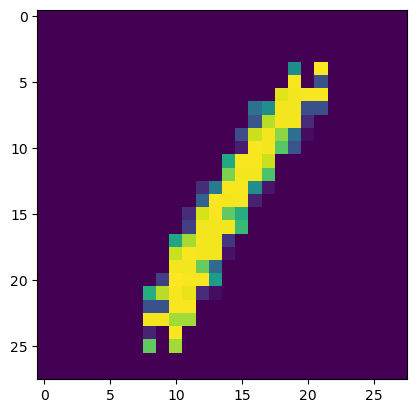

In [20]:
# image0 = tf.reshape(image, (28, 28))
# plt.Figure(figsize=(10,1))
plt.imshow(reshaped_image)


## End! Reshaping back to original 

### Fashion Mnist 

In [11]:
def preset():
     # load the data tf.keras.datasets.fashion_mnist.load_data()

    fashion_mnist_dataset = keras.datasets.fashion_mnist
    (tr_images, tr_labels), (te_images, te_labels) = fashion_mnist_dataset.load_data()
    
    # name of the folder where will save the filtered images for training
    tr_layer = mq.ConvolutionLayer4x4("_OA_results_FashionMnist_train_with_val")
    # name of the folder where will save the filtered images for testing
    te_layer = mq.ConvolutionLayer4x4("_OA_results_FashionMnist_test_with_val")
    

    tr_layer.fit(tr_images)
    te_layer.fit(te_images)
    tr_images = tr_layer.transform(tr_images)
    te_images = te_layer.transform(te_images)
    return  ((tr_images, tr_labels), (te_images, te_labels))






In [12]:
# Load the data
fashion_mnist_dataset = keras.datasets.fashion_mnist
(Data_Info["Fashion Mnist"]["Dataset"]["tr_images"],\
Data_Info["Fashion Mnist"]["Dataset"]["tr_labels"]),\
(Data_Info["Fashion Mnist"]["Dataset"]["te_images"],\
Data_Info["Fashion Mnist"]["Dataset"]["te_labels"]) = preset()


In [9]:
Data_Info["Fashion Mnist"]["Dataset"]["tr_images"].shape

(60000, 196, 4)

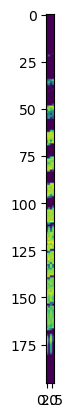

In [11]:
image0 = Data_Info["Fashion Mnist"]["Dataset"]["tr_images"][0]
plt.Figure(figsize=(14,14))
plt.imshow(image0)

## eMnist 


In [13]:
def preset():
    # Download the eMnist dataset(Matlab format dataset) from this url: 
    # https://www.nist.gov/itl/products-and-services/emnist-dataset
    # Put either emnist-digits.mat or the enire dataset in Dataset folder so you won't need
    # to change the file_name
    # "Digits"
    file_name = r"/workspaces/QML-QPF/Other_Grayscale_datastes_results/eMnist/Dataset/emnist-digits.mat"
    emnist_digit_dataset = scipy.io.loadmat(file_name)
    
    type_of_class = "Digits"
    
    # # balanced
    # file_name = r"/workspaces/QML-QPF/Other_Grayscale_datastes_results/eMnist/Dataset/emnist-balanced.mat"
    # emnist_digit_dataset = scipy.io.loadmat(file_name)
    
    # type_of_class = "Balanced"
    
    # name of the folder where will save the filtered images for training
    tr_layer = mq.ConvolutionLayer4x4(f"_OA_results_eMnist_{type_of_class}_train_with_val")
    # name of the folder where will save the filtered images for testing
    te_layer = mq.ConvolutionLayer4x4(f"_OA_results_eMnist_{type_of_class}_test_with_val")
    #load the data set want to train
    train_images = emnist_digit_dataset['dataset']['train'][0][0][0][0][0]
    tr_images = train_images.reshape(len(train_images), 28, 28, 1)
    tr_labels = emnist_digit_dataset['dataset']['train'][0][0][0][0][1]

    test_images = emnist_digit_dataset['dataset']['test'][0][0][0][0][0]
    te_images = test_images.reshape(len(test_images), 28, 28, 1)
    te_labels = emnist_digit_dataset['dataset']['test'][0][0][0][0][1]
    
    tr_layer.fit(tr_images)
    te_layer.fit(te_images)
    tr_images = tr_layer.transform(tr_images)
    te_images = te_layer.transform(te_images)
    return ((tr_images, tr_labels), (te_images, te_labels))



In [14]:
# Load the data
(Data_Info["eMnist Digits"]["Dataset"]["tr_images"],\
Data_Info["eMnist Digits"]["Dataset"]["tr_labels"]),\
(Data_Info["eMnist Digits"]["Dataset"]["te_images"],\
Data_Info["eMnist Digits"]["Dataset"]["te_labels"]) = preset()

In [15]:
Data_Info["Maximally Entangled"]

{'Dataset': {'tr_images': '',
  'tr_labels': '',
  'te_images': '',
  'te_labels': ''},
 'Configs': {'P_diagonal_config': array([0, 1, 2, 3]),
  'P_vertical_config': array([0, 1, 2, 3]),
  'P_horizontal_config': array([0, 1, 2, 3])},
 'Entropy': {'Diagonal': {'Total_Avg_Diagonal_Entropy_S1': [],
   'Total_Max_Diagonal_Entropy_S1': [],
   'Total_Avg_Diagonal_Entropy_S2': [],
   'Total_Max_Diagonal_Entropy_S2': [],
   'Total_Avg_Diagonal_Entropy_S1_S2': [],
   'Total_Max_Diagonal_Entropy_S1_S2': []},
  'Vertical': {'Total_Avg_Vertical_Entropy_S1': [],
   'Total_Max_Vertical_Entropy_S1': [],
   'Total_Avg_Vertical_Entropy_S2': [],
   'Total_Max_Vertical_Entropy_S2': [],
   'Total_Avg_Vertical_Entropy_S1_S2': [],
   'Total_Max_Vertical_Entropy_S1_S2': []},
  'Horizontal': {'Total_Avg_Horizontal_Entropy_S1': [],
   'Total_Max_Horizontal_Entropy_S1': [],
   'Total_Avg_Horizontal_Entropy_S2': [],
   'Total_Max_Horizontal_Entropy_S2': [],
   'Total_Avg_Horizontal_Entropy_S1_S2': [],
   'Total_

### Sanity Check of the code

In [24]:
import numpy as np

n, H, W = 10000, 28, 28
rng = np.random.default_rng(42)

# Allocate and fill images
imgs = np.empty((n, H, W), dtype=np.float32)

# For every 2x2 block: top-left and bottom-left are 0.5 (control ~ π/2)
imgs[:, 0::2, 0::2] = 0.5   # a
imgs[:, 1::2, 0::2] = 0.5   # c

# Targets are 0 or 1 (θ = 0 or π), chosen randomly per block and per image
t1 = rng.integers(0, 2, size=(n, H//2, W//2), dtype=np.int8)  # for b
t2 = rng.integers(0, 2, size=(n, H//2, W//2), dtype=np.int8)  # for d
imgs[:, 0::2, 1::2] = t1    # b
imgs[:, 1::2, 1::2] = t2    # d

# Optional: tiny jitter to avoid exact-boundary issues in downstream code (set eps=0 to disable)
eps = 0.0
if eps > 0:
    imgs[:, 0::2, 0::2] = np.clip(imgs[:, 0::2, 0::2] + rng.uniform(-eps, eps, imgs[:, 0::2, 0::2].shape), 0, 1)
    imgs[:, 1::2, 0::2] = np.clip(imgs[:, 1::2, 0::2] + rng.uniform(-eps, eps, imgs[:, 1::2, 0::2].shape), 0, 1)

# Unfold into non-overlapping 2x2 patches → shape (n, 196, 4) in [a, b, c, d] order
patches = imgs.reshape(n, H//2, 2, W//2, 2).transpose(0, 1, 3, 2, 4).reshape(n, (H//2)*(W//2), 4)

# Now patches[..., :2] is the first pair (a,b), and patches[..., 2:] is the second pair (c,d)
# Feeding these through your entropy routine should yield ~1 bit for both pairs.


In [17]:
patches

array([[[0.5, 1. , 0.5, 1. ],
        [0.5, 0. , 0.5, 1. ],
        [0.5, 1. , 0.5, 1. ],
        ...,
        [0.5, 0. , 0.5, 1. ],
        [0.5, 1. , 0.5, 0. ],
        [0.5, 1. , 0.5, 1. ]],

       [[0.5, 0. , 0.5, 0. ],
        [0.5, 0. , 0.5, 0. ],
        [0.5, 0. , 0.5, 1. ],
        ...,
        [0.5, 0. , 0.5, 1. ],
        [0.5, 1. , 0.5, 1. ],
        [0.5, 1. , 0.5, 1. ]],

       [[0.5, 1. , 0.5, 0. ],
        [0.5, 1. , 0.5, 1. ],
        [0.5, 0. , 0.5, 0. ],
        ...,
        [0.5, 1. , 0.5, 0. ],
        [0.5, 1. , 0.5, 0. ],
        [0.5, 0. , 0.5, 0. ]],

       ...,

       [[0.5, 0. , 0.5, 1. ],
        [0.5, 1. , 0.5, 0. ],
        [0.5, 0. , 0.5, 1. ],
        ...,
        [0.5, 1. , 0.5, 0. ],
        [0.5, 0. , 0.5, 1. ],
        [0.5, 0. , 0.5, 1. ]],

       [[0.5, 1. , 0.5, 0. ],
        [0.5, 1. , 0.5, 1. ],
        [0.5, 1. , 0.5, 0. ],
        ...,
        [0.5, 1. , 0.5, 0. ],
        [0.5, 0. , 0.5, 0. ],
        [0.5, 1. , 0.5, 1. ]],

       [[0.5

In [25]:
patches.shape

(10000, 196, 4)

In [26]:
Data_Info["Maximally Entangled"]["Dataset"]["te_images"] = patches

### Computing Entanglement

In [ ]:
# --- Function to process a single input type ---
def process_input_type(data_name, input_data, symmetry, entropy_dict_for_symm):
    """
    Helper function to encapsulate the parallel processing logic for one input type.
    """
    input_system_03 = input_data[:, :, :2]
    input_system_21 = input_data[:, :, 2:4] # Assuming the same slicing  input_system_03 = input_data[:, :, :2]

    task_inputs = list(zip(input_system_03, input_system_21))

    print(f"\nStarting parallel entropy computation for {data_name} data ({len(task_inputs)} batches)...")
    type_start_time = time.time()

    # Clear lists before appending for a new run/symmetry type
    # This assumes entropy_dict_for_symm contains lists that need to be reset for each call
    for key in entropy_dict_for_symm:
        if isinstance(entropy_dict_for_symm[key], list): # Only clear actual lists that get appended to
            entropy_dict_for_symm[key].clear()
        elif isinstance(entropy_dict_for_symm[key], np.ndarray):
            # If it's a NumPy array, replace it with an empty list.
            # Since subsequent operations involve .append(), the data structure needs to be a list.
            entropy_dict_for_symm[key] = []
            
    with concurrent.futures.ProcessPoolExecutor(max_workers=None) as executor:
        results_iterator = executor.map(compute_entropy_for_pair_batch, task_inputs)

        for i, result in enumerate(results_iterator):
            (avg_s1_rho0, avg_s1_rho1), \
            (avg_s2_rho0, avg_s2_rho1), \
            (max_s1_rho0, max_s1_rho1), \
            (max_s2_rho0, max_s2_rho1) = result[:4]
            
            (S1_rho_0_batch), \ 
            (S1_rho_1_batch), \
            (S2_rho_0_batch), \
            (S2_rho_1_batch)  = result[4:]

            # Append to the lists directly from the dictionary
            # Using dictionary keys here
            entropy_dict_for_symm['Total_Avg_' + symmetry + '_Entropy_S1'].append((avg_s1_rho0, avg_s1_rho1))
            entropy_dict_for_symm['Total_Avg_' + symmetry + '_Entropy_S2'].append((avg_s2_rho0, avg_s2_rho1))
            entropy_dict_for_symm['Total_Max_' + symmetry + '_Entropy_S1'].append((max_s1_rho0, max_s1_rho1))
            entropy_dict_for_symm['Total_Max_' + symmetry + '_Entropy_S2'].append((max_s2_rho0, max_s2_rho1))


            if (i + 1) % 100 == 0:
                print(f"Processed {i + 1}/{len(task_inputs)} batches for {symmetry}.")
                
        
        # Convert lists to NumPy arrays
        entropy_dict_for_symm['Total_Avg_' + symmetry + '_Entropy_S1'] = np.array(entropy_dict_for_symm['Total_Avg_' + symmetry + '_Entropy_S1'])
        entropy_dict_for_symm['Total_Avg_' + symmetry + '_Entropy_S2'] = np.array(entropy_dict_for_symm['Total_Avg_' + symmetry + '_Entropy_S2'])
        entropy_dict_for_symm['Total_Max_' + symmetry + '_Entropy_S1'] = np.array(entropy_dict_for_symm['Total_Max_' + symmetry + '_Entropy_S1'])
        entropy_dict_for_symm['Total_Max_' + symmetry + '_Entropy_S2'] = np.array(entropy_dict_for_symm['Total_Max_' + symmetry + '_Entropy_S2'])
        # compute the total entry of the entire system S1 + S2
        # Compute the total entropy of the entire system S1 + S2
        # Ensure avg_s1_array and avg_s2_array are in the correct shape (N, 2)
        # The output of compute_entropy_for_pair_batch is (rho0, rho1) tuples, which will become (N, 2) arrays.
        entropy_dict_for_symm['Total_Avg_' + symmetry + '_Entropy_S1_S2'] = entropy_dict_for_symm['Total_Avg_' + symmetry + '_Entropy_S1'] \
                                                                            + entropy_dict_for_symm['Total_Avg_' + symmetry + '_Entropy_S2']
        entropy_dict_for_symm[f'Total_Max_{symmetry}_Entropy_S1_S2'] = entropy_dict_for_symm['Total_Max_' + symmetry + '_Entropy_S1'] \
                                                                            + entropy_dict_for_symm['Total_Max_' + symmetry + '_Entropy_S2']

    # --- Saving Data as CSV ---
    # 1. Create the data_name specific folder
    # Sanity_Check
    # entropy_folder_name = "_OA_Sanity_Check"
    # test
    entropy_folder_name = "_OA_test"
    # train
    # entropy_folder_name = "_OA_train"
    output_folder_path = os.path.join(entropy_folder_name, data_name.replace(" ", "_"), symmetry) # Replace spaces for folder names
    os.makedirs(output_folder_path, exist_ok=True)
    print(f"Created/Ensured directory: {output_folder_path}")

    # 2. Save each list/array corresponding to each key as a CSV file
    for key, value in entropy_dict_for_symm.items():
        if isinstance(value, np.ndarray): # Only save if it's a NumPy array
            file_path = os.path.join(output_folder_path, f"{key}.csv")
            # Use fmt='%.8f' for float formatting, delimiter=',' for CSV
            np.savetxt(file_path, value, delimiter=',', fmt='%.8f')
            print(f"Saved {key}.csv to {output_folder_path}")
        else:
            print(f"Skipping saving for key '{key}' as it's not a NumPy array (type: {type(value)})")
    type_end_time = time.time()
    print(f"Finished parallel computation for {data_name} data for symmetry {symmetry} in {type_end_time - type_start_time:.2f} seconds.")


# --- Process each input type ---

overall_start_time = time.time()

# selected_data_names = ["Mnist", "Fashion Mnist", "eMnist Digits"]
# selected_data_names = ["PneumoniaMNIST"]
# selected_data_names = ["BreastMNIST", "OCTMNIST", "PneumoniaMNIST", "Mnist", "Fashion Mnist", "eMnist Digits"]
# Checking if our Entropy code returns correct results;

selected_data_names = ["Maximally Entangled"]
for data_name in selected_data_names:
    data_info = Data_Info[data_name]    
    # Scaling data
    # Train data
    # scaled_sample = Data_Info[data_name]["Dataset"]["tr_images"]/255.
    # test
    # scaled_sample = Data_Info[data_name]["Dataset"]["te_images"]/255.
    scaled_sample = Data_Info[data_name]["Dataset"]["te_images"]
    # Encoding data using angle encoding
    input = scaled_sample * np.pi
    # #  getting the configs from data
    # P_diagonal_config  = Data_Info[data_name]["Configs"]["P_diagonal_config"]
    # P_horizontal_config = Data_Info[data_name]["Configs"]["P_horizontal_config"]
    # P_vertical_config = Data_Info[data_name]["Configs"]["P_vertical_config"]
    # # rearranging the input in respect to the configs 
    # diagonal_input = input[:,:,P_diagonal_config]
    # horizontal_input = input[:,:,P_horizontal_config]
    # vertical_input = input[:,:,P_vertical_config]
    
    for (symmetry, entropy), (_, config) in zip(Data_Info[data_name]["Entropy"].items(), Data_Info[data_name] ["Configs"].items()):
        # rearranging the input in respect to the configs
        input = input[:,:,config]
        # Process Diagonal Input
        #  how can I pass through the lists(keys) of each symmtery, I can add the 2 last keys as argument to the process function 
        process_input_type(data_name ,input, symmetry, entropy)

# # Process Diagonal Input
# process_input_type(diagonal_input, "Diagonal",
#                    Total_Avg_Diagonal_Entropy_S1, Total_Max_Diagonal_Entropy_S1,
#                    Total_Avg_Diagonal_Entropy_S2, Total_Max_Diagonal_Entropy_S2)

# # Convert to NumPy arrays
# Total_Avg_Diagonal_Entropy_S1 = np.array(Total_Avg_Diagonal_Entropy_S1)
# Total_Max_Diagonal_Entropy_S1 = np.array(Total_Max_Diagonal_Entropy_S1)
# Total_Avg_Diagonal_Entropy_S2 = np.array(Total_Avg_Diagonal_Entropy_S2)
# Total_Max_Diagonal_Entropy_S2 = np.array(Total_Max_Diagonal_Entropy_S2)
# # compute the total entry of the entire system S1 + S2
# Total_Avg_Diagonal_Entropy_S1_S2 = Total_Avg_Diagonal_Entropy_S1 + Total_Avg_Diagonal_Entropy_S2
# Total_Max_Diagonal_Entropy_S1_S2 = Total_Max_Diagonal_Entropy_S1 + Total_Max_Diagonal_Entropy_S2 

# # Process Vertical Input
# process_input_type(vertical_input, "Vertical",
#                    Total_Avg_Vertical_Entropy_S1, Total_Max_Vertical_Entropy_S1,
#                    Total_Avg_Vertical_Entropy_S2, Total_Max_Vertical_Entropy_S2)

# # Convert to NumPy arrays
# Total_Avg_Vertical_Entropy_S1 = np.array(Total_Avg_Vertical_Entropy_S1)
# Total_Max_Vertical_Entropy_S1 = np.array(Total_Max_Vertical_Entropy_S1)
# Total_Avg_Vertical_Entropy_S2 = np.array(Total_Avg_Vertical_Entropy_S2)
# Total_Max_Vertical_Entropy_S2 = np.array(Total_Max_Vertical_Entropy_S2)
# # compute the total entry of the entire system S1 + S2
# Total_Avg_Vertical_Entropy_S1_S2 = Total_Avg_Vertical_Entropy_S1 + Total_Avg_Vertical_Entropy_S2 
# Total_Max_Vertical_Entropy_S1_S2 = Total_Max_Vertical_Entropy_S1 + Total_Max_Vertical_Entropy_S2


# # Process Horizontal Input
# process_input_type(horizontal_input, "Horizontal",
#                    Total_Avg_Horizontal_Entropy_S1, Total_Max_Horizontal_Entropy_S1,
#                    Total_Avg_Horizontal_Entropy_S2, Total_Max_Horizontal_Entropy_S2)

# # Convert to NumPy arrays
# Total_Avg_Horizontal_Entropy_S1 = np.array(Total_Avg_Horizontal_Entropy_S1)
# Total_Max_Horizontal_Entropy_S1 = np.array(Total_Max_Horizontal_Entropy_S1)
# Total_Avg_Horizontal_Entropy_S2 = np.array(Total_Avg_Horizontal_Entropy_S2)
# Total_Max_Horizontal_Entropy_S2 = np.array(Total_Max_Horizontal_Entropy_S2)
# # compute the total entry of the entire system S1 + S2
# Total_Avg_Horizontal_Entropy_S1_S2 = Total_Avg_Horizontal_Entropy_S1 + Total_Avg_Horizontal_Entropy_S2
# Total_Max_Horizontal_Entropy_S1_S2 = Total_Max_Horizontal_Entropy_S1 + Total_Max_Horizontal_Entropy_S2

overall_end_time = time.time()
print(f"\nAll entropy computations finished in a total of {overall_end_time - overall_start_time:.2f} seconds.")

# # --- Example: Print some results to verify ---
# print("\nFirst 5 Diagonal Average S1 results:", Total_Avg_Diagonal_Entropy_S1[:5])
# print("First 5 Vertical Average S1 results:", Total_Avg_Vertical_Entropy_S1[:5])
# print("First 5 Horizontal Average S1 results:", Total_Avg_Horizontal_Entropy_S1[:5])



Starting parallel entropy computation for Maximally Entangled data (10000 batches)...


Processed 100/10000 batches for Diagonal.
Processed 200/10000 batches for Diagonal.
Processed 300/10000 batches for Diagonal.
Processed 400/10000 batches for Diagonal.
Processed 500/10000 batches for Diagonal.
Processed 600/10000 batches for Diagonal.
Processed 700/10000 batches for Diagonal.
Processed 800/10000 batches for Diagonal.
Processed 900/10000 batches for Diagonal.
Processed 1000/10000 batches for Diagonal.
Processed 1100/10000 batches for Diagonal.
Processed 1200/10000 batches for Diagonal.
Processed 1300/10000 batches for Diagonal.
Processed 1400/10000 batches for Diagonal.
Processed 1500/10000 batches for Diagonal.
Processed 1600/10000 batches for Diagonal.
Processed 1700/10000 batches for Diagonal.
Processed 1800/10000 batches for Diagonal.
Processed 1900/10000 batches for Diagonal.
Processed 2000/10000 batches for Diagonal.
Processed 2100/10000 batches for Diagonal.
Processed 2200/10000 batches for Diagonal.
Processed 2300/10000 batches for Diagonal.
Processed 2400/10000

In [28]:
Data_Info['Maximally Entangled']['Entropy']['Diagonal']['Total_Avg_Diagonal_Entropy_S1_S2'].shape

(10000, 2)

In [7]:
# selected_data_names = ["BreastMNIST", "OCTMNIST", "PneumoniaMNIST", "Mnist", "Fashion Mnist", "eMnist Digits"]
selected_data_names = ["Maximally Entangled"]

for data_name in selected_data_names:
    data_info = Data_Info[data_name]
    print(f"dataname {data_name}")
    # scaled_sample = Data_Info[data_name]["Dataset"]["te_images"]/255.
    print(Data_Info[data_name]["Entropy"])
    

dataname Maximally Entangled
{'Diagonal': {'Total_Avg_Diagonal_Entropy_S1': array([[1.00000003, 1.00000003],
       [1.00000003, 1.00000003],
       [1.00000003, 1.00000003],
       ...,
       [1.00000003, 1.00000003],
       [1.00000003, 1.00000003],
       [1.00000003, 1.00000003]]), 'Total_Max_Diagonal_Entropy_S1': array([[1.00000003, 1.00000003],
       [1.00000003, 1.00000003],
       [1.00000003, 1.00000003],
       ...,
       [1.00000003, 1.00000003],
       [1.00000003, 1.00000003],
       [1.00000003, 1.00000003]]), 'Total_Avg_Diagonal_Entropy_S2': array([[1.00000003, 1.00000003],
       [1.00000003, 1.00000003],
       [1.00000003, 1.00000003],
       ...,
       [1.00000003, 1.00000003],
       [1.00000003, 1.00000003],
       [1.00000003, 1.00000003]]), 'Total_Max_Diagonal_Entropy_S2': array([[1.00000003, 1.00000003],
       [1.00000003, 1.00000003],
       [1.00000003, 1.00000003],
       ...,
       [1.00000003, 1.00000003],
       [1.00000003, 1.00000003],
       [1.00

In [17]:
Data_Info.keys()

dict_keys(['Mnist', 'Fashion Mnist', 'eMnist Digits', 'PneumoniaMNIST', 'BreastMNIST', 'OCTMNIST'])

In [13]:
D = Data_Info["Mnist"]["Entropy"]["Diagonal"]["Total_Avg_Diagonal_Entropy_S1"]
np.mean(D, axis=0)

array([0.05309656, 0.05309656])

## Mnist 

S1

In [14]:
D = Data_Info["Mnist"]["Entropy"]["Diagonal"]["Total_Avg_Diagonal_Entropy_S1"]
Mnist_Avg_Diagonal, Mnist_Avg_Diagonal_var = np.mean(D, axis=0), np.var(D, axis=0)
V = Data_Info["Mnist"]["Entropy"]["Vertical"]["Total_Avg_Vertical_Entropy_S1"]
Mnist_Avg_Vertical, Mnist_Avg_Vertical_var = np.mean(V, axis=0), np.var(D, axis=0)
H = Data_Info["Mnist"]["Entropy"]["Horizontal"]["Total_Avg_Horizontal_Entropy_S1"]
Mnist_Avg_Horizontal, Mnist_Avg_Horizontal_var = np.mean(H, axis=0), np.var(D, axis=0)
print(f"Diagonal")
print(f"Mnist_Avg_Diagonal {Mnist_Avg_Diagonal}, Mnist_Avg_Diagonal_var {Mnist_Avg_Diagonal_var}")
print("#"*80)
print(f"Vertical")
print(f"Mnist_Avg_Vertical {Mnist_Avg_Vertical}, Mnist_Avg_Vertical_var {Mnist_Avg_Vertical_var}")
print("#"*80)

print(f"Horizontal")
print(f"Mnist_Avg_Horizontal {Mnist_Avg_Horizontal}, Mnist_Avg_Horizontal_var {Mnist_Avg_Horizontal_var}")
print("#"*80)



Diagonal
Mnist_Avg_Diagonal [0.05309656 0.05309656], Mnist_Avg_Diagonal_var [0.00025248 0.00025248]
################################################################################
Vertical
Mnist_Avg_Vertical [0.05345944 0.05345944], Mnist_Avg_Vertical_var [0.00025248 0.00025248]
################################################################################
Vertical
Mnist_Avg_Horizontal [0.04902366 0.04902366], Mnist_Avg_Horizontal_var [0.00025248 0.00025248]
################################################################################


S1 + S2

In [ ]:
D = Data_Info["Mnist"]["Entropy"]["Diagonal"]["Total_Avg_Diagonal_Entropy_S1_S2"]
Mnist_Avg_Diagonal, Mnist_Avg_Diagonal_var = np.mean(D, axis=0), np.var(D, axis=0)
V = Data_Info["Mnist"]["Entropy"]["Vertical"]["Total_Avg_Vertical_Entropy_S1_S2"]
Mnist_Avg_Vertical, Mnist_Avg_Vertical_var = np.mean(V, axis=0), np.var(D, axis=0)
H = Data_Info["Mnist"]["Entropy"]["Horizontal"]["Total_Avg_Horizontal_Entropy_S1_S2"]
Mnist_Avg_Horizontal, Mnist_Avg_Horizontal_var = np.mean(H, axis=0), np.var(D, axis=0)
print(f"S1 + S2")
print(f"Diagonal")
print(f"Mnist_Avg_Diagonal {Mnist_Avg_Diagonal}, Mnist_Avg_Diagonal_var {Mnist_Avg_Diagonal_var}")
print("#"*80)
print(f"Vertical")
print(f"Mnist_Avg_Vertical {Mnist_Avg_Vertical}, Mnist_Avg_Vertical_var {Mnist_Avg_Vertical_var}")
print("#"*80)

print(f"Horizontal")
print(f"Mnist_Avg_Horizontal {Mnist_Avg_Horizontal}, Mnist_Avg_Horizontal_var {Mnist_Avg_Horizontal_var}")
print("#"*80)


Diagonal
Mnist_Avg_Diagonal [0.10619312 0.10619312], Mnist_Avg_Diagonal_var [0.00100991 0.00100991]
################################################################################
Vertical
Mnist_Avg_Vertical [0.10691887 0.10691887], Mnist_Avg_Vertical_var [0.00100991 0.00100991]
################################################################################
Vertical
Mnist_Avg_Horizontal [0.09804731 0.09804731], Mnist_Avg_Horizontal_var [0.00100991 0.00100991]
################################################################################


## Printing the Avg and Var

In [8]:
import numpy as np
import os

# --- Configuration (must match your saving script) ---
BASE_DATA_DIR = "" # Empty string means current directory

# --- Define the specific data names and symmetries to process ---
# selected_data_names = ["Mnist", "Fashion Mnist", "eMnist Digits"]
# selected_data_names = ["PneumoniaMNIST"]
# selected_data_names = ["BreastMNIST", "OCTMNIST", "PneumoniaMNIST", "Mnist", "Fashion Mnist", "eMnist Digits"]
selected_data_names = ["Maximally Entangled"]

symmetries = ["Diagonal", "Vertical", "Horizontal"]

# --- Function to process and print statistics from a CSV file ---
def analyze_entropy_file(file_path, data_name, symmetry_name, entropy_key):
    try:
        # Load the data from the CSV file
        data = np.loadtxt(file_path, delimiter=',')

        # Handle cases where data might be a single value or 1D array
        if data.ndim == 0: # A single number
            data = np.array([data])
        elif data.ndim == 1: # A single column or row
            # If it's (N,), mean/var will be single values.
            # If it's (N, 2), it will remain (N, 2).
            pass # np.mean and np.var handle 1D arrays correctly for axis=0

        # Compute average (mean) along axis=0 (for each column)
        avg_values = np.mean(data, axis=0)
        # Compute variance along axis=0 (for each column)
        var_values = np.var(data, axis=0)
        # Compute Standard Deviation along axis=0 (for each column)
        std_values = np.std(data, axis=0)
        

        print(f"\n--- Analysis for: {data_name} / {symmetry_name} / {entropy_key} ---")
        print(f"File: {file_path}")
        print(f"Data Shape: {data.shape}")
        print(f"Average (Mean) per column: {avg_values}")
        print(f"Variance per column: {var_values}")
        print(f"Standard Deviation per column: {std_values}")

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# --- Main script to traverse directories and analyze files ---

# Iterate through items in the base directory
entropy_folder_name = "_OA_Sanity_Check"
# test
# entropy_folder_name = "_OA_test"
# train
# entropy_folder_name = "_OA_train"
# print(os.listdir(os.path.join(os.path.abspath(BASE_DATA_DIR), entropy_folder_name)))
for data_name_folder_raw in os.listdir(os.path.join(os.path.abspath(BASE_DATA_DIR), entropy_folder_name)):
    # Normalize folder name to match our list (e.g., "Mnist_" -> "Mnist")
    current_data_name = data_name_folder_raw.replace("_", " ").strip()
    # print(current_data_name)
    # Skip if this data_name is not in our desired list
    if current_data_name not in selected_data_names:
        continue

    data_folder_path = os.path.join(BASE_DATA_DIR, entropy_folder_name ,data_name_folder_raw)
    # print(f"data_folder_path {data_folder_path}")

    # Ensure it's a directory
    if not os.path.isdir(data_folder_path):
        continue # Skip if it's not a directory

    print(f"\nProcessing data type folder: {current_data_name}")

    # Iterate through subfolders (symmetry folders)
    for symmetry_name_folder_raw in os.listdir(data_folder_path):
        # Normalize folder name to match our list
        current_symmetry_name = symmetry_name_folder_raw.replace("_", " ").strip()

        # Skip if this symmetry is not in our desired list
        if current_symmetry_name not in symmetries:
            continue

        symmetry_folder_path = os.path.join(data_folder_path, symmetry_name_folder_raw)

        # Ensure it's a directory
        if not os.path.isdir(symmetry_folder_path):
            continue # Skip if it's not a directory

        print(f"  Processing symmetry folder: {current_symmetry_name}")

        # Iterate through CSV files in the symmetry folder
        for file_name in os.listdir(symmetry_folder_path):
            if file_name.endswith('.csv'):
                file_path = os.path.join(symmetry_folder_path, file_name)
                # Extract the entropy key (remove .csv extension)
                entropy_key = os.path.splitext(file_name)[0]

                # Analyze the file
                analyze_entropy_file(file_path, current_data_name, current_symmetry_name, entropy_key)

print("\nAnalysis complete.")


Processing data type folder: Maximally Entangled
  Processing symmetry folder: Diagonal

--- Analysis for: Maximally Entangled / Diagonal / Total_Max_Diagonal_Entropy_S2 ---
File: _OA_Sanity_Check/Maximally_Entangled/Diagonal/Total_Max_Diagonal_Entropy_S2.csv
Data Shape: (10000, 2)
Average (Mean) per column: [1.00000003 1.00000003]
Variance per column: [4.93038066e-30 4.93038066e-30]
Standard Deviation per column: [2.22044605e-15 2.22044605e-15]

--- Analysis for: Maximally Entangled / Diagonal / Total_Avg_Diagonal_Entropy_S1 ---
File: _OA_Sanity_Check/Maximally_Entangled/Diagonal/Total_Avg_Diagonal_Entropy_S1.csv
Data Shape: (10000, 2)
Average (Mean) per column: [1.00000003 1.00000003]
Variance per column: [4.93038066e-30 4.93038066e-30]
Standard Deviation per column: [2.22044605e-15 2.22044605e-15]

--- Analysis for: Maximally Entangled / Diagonal / Total_Avg_Diagonal_Entropy_S1_S2 ---
File: _OA_Sanity_Check/Maximally_Entangled/Diagonal/Total_Avg_Diagonal_Entropy_S1_S2.csv
Data Shap

In [21]:
for data_name_folder_raw in os.listdir(os.path.join(os.path.abspath(BASE_DATA_DIR), "_OA_")):
    # Normalize folder name to match our list (e.g., "Mnist_" -> "Mnist")
    current_data_name = data_name_folder_raw.replace("_", " ").strip()
    print(current_data_name)

Fashion Mnist
eMnist Digits
PneumoniaMNIST
Mnist


In [19]:
BASE_DATA_DIR = ""
print(f"Starting analysis in base directory: {os.path.abspath(BASE_DATA_DIR)}")


Starting analysis in base directory: /workspaces/QML-QPF/Quantifying_Entanglement


In [4]:
def change_dict(dicto):
    dicto["Total_Avg_Diagonal_Entropy_S1"].append((0,1,2,3))
    
    
d = {"Total_Avg_Diagonal_Entropy_S1":[]}
print(d)
change_dict(d)
print(d)

{'Total_Avg_Diagonal_Entropy_S1': []}
{'Total_Avg_Diagonal_Entropy_S1': [(0, 1, 2, 3)]}


In [37]:
**entropy

SyntaxError: invalid syntax (1098917468.py, line 1)

In [ ]:
for j, (ki, _) in enumerate(entropy.items()):
    # taking only the 1st four element
    if j >3: break
    print(entropy[ki], j)
    

[0, 1, 2, 3, 4] 0
[0, 1, 2, 3, 4] 1
[0, 1, 2, 3, 4] 2
[0, 1, 2, 3, 4] 3


In [27]:
for (symmetry, entropy), (_, config) in zip(Data_Info["Mnist"]["Entropy"].items(), Data_Info["Mnist"]["Configs"].items()):
    print(symmetry)
    print(config)
    for ki, vi in entropy.items():
        print(ki, vi)
        entropy[ki] = list(range(5))

Diagonal
[0 3 2 1]
Total_Avg_Diagonal_Entropy_S1 []
Total_Max_Diagonal_Entropy_S1 []
Total_Avg_Diagonal_Entropy_S2 []
Total_Max_Diagonal_Entropy_S2 []
Total_Avg_Diagonal_Entropy_S1_S2 []
Total_Max_Diagonal_Entropy_S1_S2 []
Vertical
[1 0 3 2]
Total_Avg_Vertical_Entropy_S1 []
Total_Max_Vertical_Entropy_S1 []
Total_Avg_Vertical_Entropy_S2 []
Total_Max_Vertical_Entropy_S2 []
Total_Avg_Vertical_Entropy_S1_S2 []
Total_Max_Vertical_Entropy_S1_S2 []
Horizontal
[1 3 2 0]
Total_Avg_Horizontal_Entropy_S1 []
Total_Max_Horizontal_Entropy_S1 []
Total_Avg_Horizontal_Entropy_S2 []
Total_Max_Horizontal_Entropy_S2 []
Total_Avg_Horizontal_Entropy_S1_S2 []
Total_Max_Horizontal_Entropy_S1_S2 []


In [25]:
entropy

{'Total_Avg_Horizontal_Entropy_S1': [0, 1, 2, 3, 4],
 'Total_Max_Horizontal_Entropy_S1': [0, 1, 2, 3, 4],
 'Total_Avg_Horizontal_Entropy_S2': [0, 1, 2, 3, 4],
 'Total_Max_Horizontal_Entropy_S2': [0, 1, 2, 3, 4],
 'Total_Avg_Horizontal_Entropy_S1_S2': [0, 1, 2, 3, 4],
 'Total_Max_Horizontal_Entropy_S1_S2': [0, 1, 2, 3, 4]}

In [7]:
Data_Info["Mnist"]

{'Dataset': {'tr_images': '',
  'tr_labels': '',
  'te_images': '',
  'te_labels': ''},
 'Entropy': {'Diagonal': {'Total_Avg_Diagonal_Entropy_S1': [],
   'Total_Max_Diagonal_Entropy_S1': [],
   'Total_Avg_Diagonal_Entropy_S2': [],
   'Total_Max_Diagonal_Entropy_S2': [],
   'Total_Avg_Diagonal_Entropy_S1_S2': [],
   'Total_Max_Diagonal_Entropy_S1_S2': []},
  'Vertical': {'Total_Avg_Vertical_Entropy_S1': [],
   'Total_Max_Vertical_Entropy_S1': [],
   'Total_Avg_Vertical_Entropy_S2': [],
   'Total_Max_Vertical_Entropy_S2': [],
   'Total_Avg_Vertical_Entropy_S1_S2': [],
   'Total_Max_Vertical_Entropy_S1_S2': []},
  'Horizontal': {'Total_Avg_Horizontal_Entropy_S1': [],
   'Total_Max_Horizontal_Entropy_S1': [],
   'Total_Avg_Horizontal_Entropy_S2': [],
   'Total_Max_Horizontal_Entropy_S2': [],
   'Total_Avg_Horizontal_Entropy_S1_S2': [],
   'Total_Max_Horizontal_Entropy_S1_S2': []}}}